In [ ]:
!pip install dnspython cryptography graphviz

!apt-get update -qq
!apt-get install graphviz -y

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 4.3 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


## Chunk 2

In [ ]:
import dns.resolver
import dns.dnssec
import dns.name
import dns.rdatatype

from graphviz import Digraph

from datetime import datetime

import dns.dnssec
from datetime import datetime, UTC

DNSSEC_ALGORITHMS = {
    1: "RSA/MD5",
    5: "RSA/SHA1",
    7: "RSASHA1-NSEC3-SHA1",
    8: "RSA/SHA256",
    10: "RSA/SHA512",
    13: "ECDSA P-256 SHA256",
    14: "ECDSA P-384 SHA384",
    15: "Ed25519",
    16: "Ed448"
}

AUTHORIZED_ALGOS = [8,10,13,14,15,16]

## Chunk 3

In [ ]:
def classify_key(flags):

    if flags == 257:
        return "KSK"

    elif flags == 256:
        return "ZSK"

    return "UNKNOWN"


def build_chain(domain):

    labels = domain.split('.')

    chain = ['.']

    current = ""

    for label in reversed(labels):

        if current == "":
            current = label
        else:
            current = label + "." + current

        chain.append(current)

    return chain


def algorithm_name(alg):

    return DNSSEC_ALGORITHMS.get(
        alg,
        f"Unknown ({alg})"
    )

## Chunk 4

In [ ]:
import dns.message
import dns.query
import dns.flags

def dnssec_query(domain, rdtype):

    request = dns.message.make_query(
        domain,
        rdtype,
        want_dnssec=True
    )

    response = dns.query.udp(
        request,
        "8.8.8.8"
    )

    return response

def analyze_dnskey(domain):

    result = []

    try:

        response = dnssec_query(
            domain,
            "DNSKEY"
        )

        for rrset in response.answer:

            if rrset.rdtype != dns.rdatatype.DNSKEY:
                continue

            for key in rrset:

                result.append({

                    "ttl": rrset.ttl,

                    "key_tag":
                    dns.dnssec.key_id(key),

                    "type":
                    "KSK"
                    if key.flags == 257
                    else "ZSK",

                    "algorithm":
                    algorithm_name(
                        key.algorithm
                    ),

                    "algorithm_id":
                    key.algorithm,

                    "authorized":
                    key.algorithm in AUTHORIZED_ALGOS,

                    "dnskey_obj":
                    key
                })

    except Exception as e:

        print(
            "DNSKEY error:",
            e
        )

    return result
from datetime import datetime, UTC

def analyze_rrsig(domain):

    result = []

    try:

        response = dnssec_query(
            domain,
            "DNSKEY"
        )

        for rrset in response.answer:

            if rrset.rdtype != dns.rdatatype.RRSIG:
                continue

            for sig in rrset:

                inception = datetime.fromtimestamp(
                    sig.inception,
                    UTC
                )

                expiration = datetime.fromtimestamp(
                    sig.expiration,
                    UTC
                )

                now = datetime.now(UTC)

                if inception <= now <= expiration:
                    status = "VALID"
                else:
                    status = "EXPIRED"

                result.append({

                  "ttl": rrset.ttl,

                  "covered":
                  dns.rdatatype.to_text(
                      sig.type_covered
                  ),

                  "signer":
                  str(sig.signer),

                  "algorithm":
                  algorithm_name(
                      sig.algorithm
                  ),

                  "key_tag":
                  sig.key_tag,

                  "inception":
                  inception,

                  "expiration":
                  expiration,

                  "status":
                  status
              })

    except Exception as e:

        print(
            "RRSIG error:",
            e
        )

    return result

def analyze_ds(domain):

    result = []

    try:

        response = dnssec_query(
            domain,
            "DS"
        )

        for rrset in response.answer:

            if rrset.rdtype != dns.rdatatype.DS:
                continue

            for ds in rrset:

                result.append({

                  "ttl": rrset.ttl,

                  "key_tag":
                  ds.key_tag,

                  "algorithm":
                  algorithm_name(
                      ds.algorithm
                  ),

                  "digest_type":
                  int(ds.digest_type),

                  "digest":
                  ds.digest.hex()
              })

    except:
        pass

    return result

def analyze_nsec(domain):

    result = {}

    try:

        response = dnssec_query(
            domain,
            "NSEC"
        )

        for rrset in response.answer:

            if rrset.rdtype == dns.rdatatype.NSEC:

                result["type"] = "NSEC"
                result["ttl"] = rrset.ttl

                return result

    except:
        pass

    try:

        response = dnssec_query(
            domain,
            "NSEC3PARAM"
        )

        for rrset in response.answer:

            if rrset.rdtype == dns.rdatatype.NSEC3PARAM:

                for r in rrset:

                    result["type"] = "NSEC3"
                    result["ttl"] = rrset.ttl

                    if r.algorithm == 1:
                        algo = "SHA-1"
                    else:
                        algo = f"Unknown ({r.algorithm})"

                    result["hash_algorithm"] = algo
                    result["iterations"] = r.iterations

    except:
      pass

    return result

def verify_ds_dnskey(domain):

    try:

        ds_records = analyze_ds(domain)

        dnskeys = dnssec_query(
            domain,
            "DNSKEY"
        )

        child_name = dns.name.from_text(
            domain
        )

        matches = []

        for rrset in dnskeys.answer:

            if rrset.rdtype != dns.rdatatype.DNSKEY:
                continue

            for key in rrset:

                if key.flags != 257:
                    continue

                for ds in ds_records:

                    generated_ds = dns.dnssec.make_ds(
                        child_name,
                        key,
                        ds["digest_type"]
                    )

                    if (
                        generated_ds.digest.hex()
                        ==
                        ds["digest"]
                    ):

                        matches.append(
                            dns.dnssec.key_id(
                                key
                            )
                        )

        return len(matches) > 0

    except:

        return False

def trust_chain_status(domain):

    if domain == ".":
        return True

    try:

        ds_ok = verify_ds_dnskey(domain)

        return ds_ok

    except:
        return False

def uses_dnssec(domain):

    try:

        dnskeys = analyze_dnskey(domain)
        rrsigs = analyze_rrsig(domain)

        if len(dnskeys) > 0 and len(rrsigs) > 0:
            return True

        return False

    except:
        return False

def child_domain(chain, index):

    if index + 1 < len(chain):
        return chain[index + 1]

    return None

## Chunk 5

## Chunk 6

In [ ]:
def build_dnssec_graph(domain):

    graph = Digraph()

    graph.attr(rankdir="TB")

    chain = build_chain(domain)

    previous = None

    for idx, node in enumerate(chain):

        graph.node(
            node,
            node,
            shape="ellipse"
        )

        if previous:
            graph.edge(
                previous,
                node
            )

        previous = node

        if node == ".":
            continue

        # DNSKEY

        for key in analyze_dnskey(node):

            kid = (
                f"{node}_"
                f"{key['key_tag']}"
            )

            graph.node(
              kid,
              f"{key['type']}\n"
              f"KeyTag: {key['key_tag']}\n"
              f"TTL: {key['ttl']} s\n"
              f"Algoritmo:\n{key['algorithm']}\n"
              f"Autorizado: {key['authorized']}",
              shape="box"
              )

            graph.edge(
                node,
                kid
            )

        # DS

        next_domain = child_domain(
            chain,
            idx
        )

        for ds in analyze_ds(node):

            did = (
                f"{node}_DS_"
                f"{ds['key_tag']}"
            )

            if next_domain:

                label = (
                    f"DS → {next_domain}\n"
                    f"KeyTag: {ds['key_tag']}\n"
                    f"TTL: {ds['ttl']} s\n"
                    f"{ds['algorithm']}"
                )

            else:

                label = (
                    f"DS\n"
                    f"KeyTag: {ds['key_tag']}\n"
                    f"TTL: {ds['ttl']} s\n"
                    f"{ds['algorithm']}"
                )

            graph.node(
                did,
                label,
                shape="box"
            )

            graph.edge(
                node,
                did
            )

        # RRSIG

        for idx, sig in enumerate(analyze_rrsig(node)):

          sid = f"{node}_SIG_{idx}"

          label = (
            f"RRSIG\n"
            f"RRSet: {sig['covered']}\n"
            f"TTL: {sig['ttl']} s\n"
            f"Estado: {sig['status']}\n"
            f"Firmante: {sig['signer']}\n"
            f"KeyTag: {sig['key_tag']}\n"
            f"Inicio:\n{sig['inception']}\n"
            f"Expira:\n{sig['expiration']}"
        )

          graph.node(
            sid,
            label,
            shape="box"
        )

          graph.edge(
            node,
            sid
          )

        # NSEC

        nsec = analyze_nsec(node)

        if nsec:

            nid = f"{node}_NSEC"

            if nsec["type"] == "NSEC":

                label = (
                    f"NSEC\n"
                    f"TTL: {nsec['ttl']} s"
                )

            else:

                label = (
                    f"NSEC3\n"
                    f"TTL: {nsec['ttl']} s\n"
                    f"Algoritmo Hash:\n"
                    f"{nsec['hash_algorithm']}\n"
                    f"Iterations: {nsec['iterations']}"
                )

            graph.node(
                nid,
                label,
                shape="box"
            )

            graph.edge(
                node,
                nid
            )


        ds_ok = verify_ds_dnskey(node)

        ds_node = f"{node}_DSCHECK"

        graph.node(
            ds_node,
            (
                "DS ↔ DNSKEY\n"
                f"{'✓ Coincide' if ds_ok else '✗ No coincide'}"
            ),
            shape="box"
        )

        graph.edge(
            node,
            ds_node
        )

        # =====================
        # CADENA DE CONFIANZA
        # =====================

        trust_ok = trust_chain_status(node)

        trust_node = f"{node}_TRUST"

        graph.node(
            trust_node,
            (
                "Cadena de confianza\n"
                f"{'✓ Íntegra' if trust_ok else '✗ Rota'}"
            ),
            shape="box"
        )

        graph.edge(
            node,
            trust_node
        )

        # =====================
        # DNSSEC
        # =====================

        dnssec_ok = uses_dnssec(node)

        dnssec_node = f"{node}_DNSSEC"

        graph.node(
            dnssec_node,
            (
                "DNSSEC\n"
                f"{'✓ Habilitado' if dnssec_ok else '✗ No habilitado'}"
            ),
            shape="box"
        )

        graph.edge(
            node,
            dnssec_node
        )

    return graph

## Chunk 7

In [ ]:
from graphviz import Digraph

def build_trust_graph(domain):

    graph = Digraph()

    graph.attr(rankdir="TB")

    chain = build_chain(domain)

    previous = None

    for node in chain:

        # Dominio
        graph.node(
            node,
            node,
            shape="ellipse"
        )

        if previous:
            graph.edge(
                previous,
                node
            )

        previous = node

        if node == ".":
            continue

        # =====================
        # DS ↔ DNSKEY
        # =====================

        ds_ok = verify_ds_dnskey(node)

        ds_node = f"{node}_DSCHECK"

        dnssec_ok = uses_dnssec(node)

        graph.node(
            ds_node,
            (
                "DS ↔ DNSKEY\n"
                + ("✓ Coincide" if ds_ok else "✗ No coincide")
            ),
            shape="box"
        )

        graph.edge(
            node,
            ds_node
        )

        # =====================
        # Cadena de confianza
        # =====================

        trust_ok = trust_chain_status(node)

        trust_node = f"{node}_TRUST"

        graph.node(
            trust_node,
            (
                "Cadena de confianza\n"
                + ("✓ Íntegra" if trust_ok else "✗ Rota")
            ),
            shape="box"
        )

        graph.edge(
            node,
            trust_node
        )

        dnssec_node = f"{node}_DNSSEC"

        graph.node(
            dnssec_node,
            (
                "DNSSEC\n"
                f"{'✓ Habilitado' if dnssec_ok else '✗ Sin suficiente evidencia para afirmar'}"
            ),
            shape="box"
        )

        graph.edge(
            node,
            dnssec_node
        )

    return graph

Dominio a analizar: unam.mx

========== DNSKEY ==========
{'ttl': 7092, 'key_tag': 42326, 'type': 'ZSK', 'algorithm': 'ECDSA P-256 SHA256', 'algorithm_id': <Algorithm.ECDSAP256SHA256: 13>, 'authorized': True, 'dnskey_obj': <DNS IN DNSKEY rdata: 256 3 13 k3aQLYzeWL2MigiAPt8DdZGTXNHzsdvk kmYJ9aWeh2U1eQfoWOlnWs1ZPWUH4orN S2Di0KXLkA4QK+74lN+mLA==>}
{'ttl': 7092, 'key_tag': 54058, 'type': 'KSK', 'algorithm': 'ECDSA P-256 SHA256', 'algorithm_id': <Algorithm.ECDSAP256SHA256: 13>, 'authorized': True, 'dnskey_obj': <DNS IN DNSKEY rdata: 257 3 13 AbAMgLJhQLFvPgAxt2J2P7Ity1taP68p YGtULy8JtDT2NMjx/a5dyMZKklaYZPoa CzClVrRfTzsvpzBblllhwA==>}

========== DS ==========
{'ttl': 21600, 'key_tag': 54058, 'algorithm': 'ECDSA P-256 SHA256', 'digest_type': 2, 'digest': 'ea3eb01183e5bc13acac4692831ea81da9b6d8f402ab3ab4fa1a5c1ef52869e0'}

========== RRSIG ==========
{'ttl': 7200, 'covered': 'DNSKEY', 'signer': 'unam.mx.', 'algorithm': 'ECDSA P-256 SHA256', 'key_tag': 42326, 'inception': datetime.datetime(2026

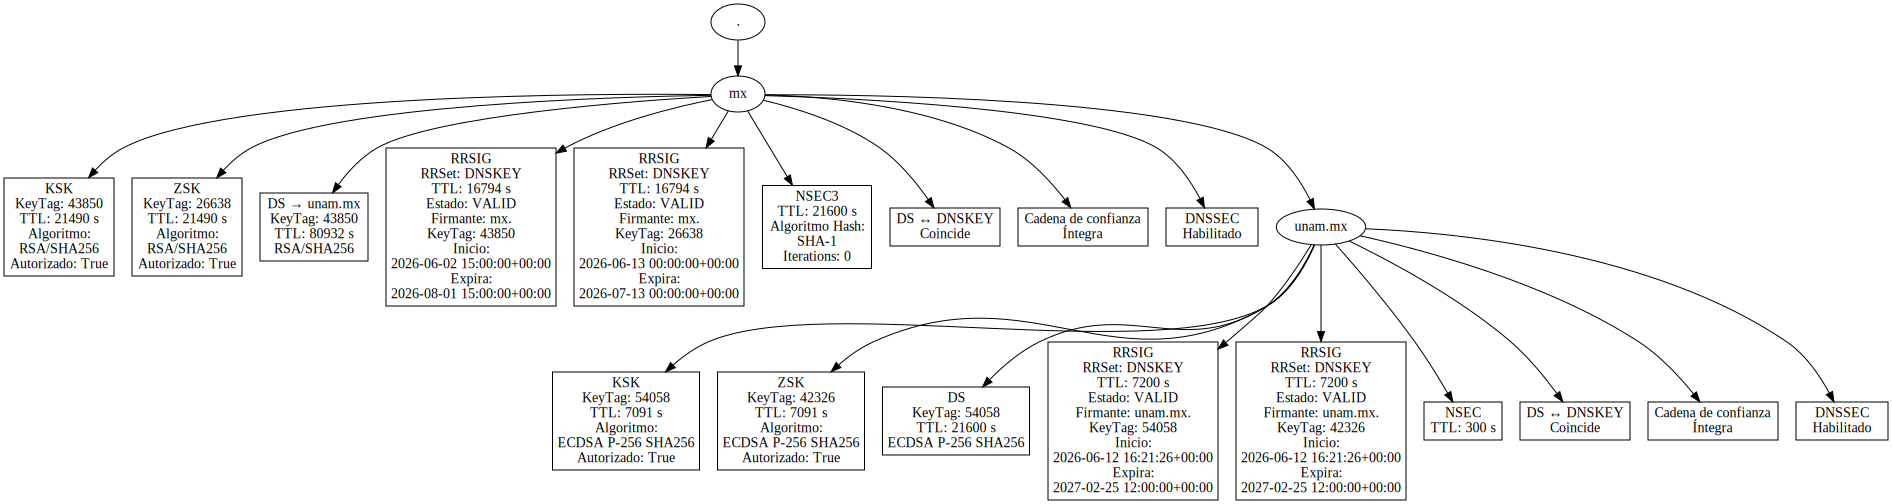

In [ ]:
# ======================================
# PROGRAMA PRINCIPAL
# ======================================

domain = input("Dominio a analizar: ").strip()

print("\n========== DNSKEY ==========")

for key in analyze_dnskey(domain):
    print(key)

print("\n========== DS ==========")

for ds in analyze_ds(domain):
    print(ds)

print("\n========== RRSIG ==========")

for sig in analyze_rrsig(domain):
    print(sig)

print("\n========== NSEC/NSEC3 ==========")

print(analyze_nsec(domain))

print("\n========== VALIDACIONES ==========")

print(
    "DS ↔ DNSKEY:",
    verify_ds_dnskey(domain)
)

graph = build_dnssec_graph(domain)

graph.render(
    "dnssec_tree",
    format="png",
    cleanup=True
)

graph

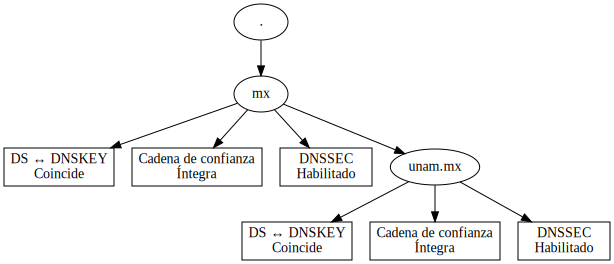

In [ ]:
trust_graph = build_trust_graph(domain)

trust_graph.render(
    "dnssec_trust_tree",
    format="png",
    cleanup=True
)

trust_graph

In [ ]:
import csv
import random
import pandas as pd



In [ ]:
def get_key_size(key):

    try:

        alg = key.algorithm

        if alg in [13]:
            return 256

        elif alg in [14]:
            return 384

        elif alg == 15:
            return 256

        elif alg == 16:
            return 456

        else:

            key_text = key.to_text()

            parts = key_text.split()

            public_key = parts[-1]

            return len(public_key) * 6

    except:

        return None

In [ ]:
def dnssec_summary(domain):

    result = {

        "Dominio": domain,
        "DNSSEC activo": "No",
        "Valida": "No",
        "Motivo": "",
        "NSEC": "N/A",
        "Algoritmo": "N/A",
        "Keysize bits": "",
        "RRsets firmadas": 0,
        "DS en zona padre": "No"
    }

    try:

        dnskeys = analyze_dnskey(domain)

        if len(dnskeys) == 0:

            result["Motivo"] = "No DNSKEY"

            return result

        result["DNSSEC activo"] = "Si"

        result["Algoritmo"] = dnskeys[0]["algorithm"]

        result["Keysize bits"] = get_key_size(
        dnskeys[0]["dnskey_obj"]
    )

        rrsigs = analyze_rrsig(domain)

        result["RRsets firmadas"] = len(rrsigs)

        if len(rrsigs) == 0:

            result["Motivo"] = "No RRSIG"

            return result

        ds_ok = verify_ds_dnskey(domain)

        result["DS en zona padre"] = (
            "Si" if len(analyze_ds(domain)) > 0
            else "No"
        )

        if not ds_ok:

            result["Motivo"] = (
                "DS no coincide con DNSKEY"
            )

            return result

        nsec = analyze_nsec(domain)

        if nsec:

            result["NSEC"] = nsec["type"]

        result["Valida"] = "Si"

        result["Motivo"] = ""

    except Exception as e:

        result["Motivo"] = str(e)

    return result

In [ ]:
def get_key_size(dnskey):

    try:

        alg = dnskey.algorithm

        if alg == 13:
            return 256

        elif alg == 14:
            return 384

        elif alg == 15:
            return 256

        elif alg == 16:
            return 456

        elif alg in [5,7,8,10]:

            public_key = dnskey.key

            if public_key[0] == 0:

                exponent_len = (
                    public_key[1] << 8
                    |
                    public_key[2]
                )

                modulus = public_key[
                    exponent_len + 3:
                ]

            else:

                exponent_len = public_key[0]

                modulus = public_key[
                    exponent_len + 1:
                ]

            return len(modulus) * 8

    except:

        return None

In [ ]:
import requests

def get_random_mx_domains(limit=100):

    domains = set()

    try:

        url = (
            "https://crt.sh/"
            "?q=%25.mx&output=json"
        )

        data = requests.get(
            url,
            timeout=30
        ).json()

        for item in data:

            name = item["name_value"]

            for d in name.split("\n"):

                d = d.strip().lower()

                if d.endswith(".mx"):

                    domains.add(d)

        domains = list(domains)

        random.shuffle(domains)

        return domains[:limit]

    except:

        return []

In [ ]:
import base64

def get_key_size(dnskey):

    try:

        alg = dnskey.algorithm

        # ECDSA P-256
        if alg == 13:
            return 256

        # ECDSA P-384
        elif alg == 14:
            return 384

        # Ed25519
        elif alg == 15:
            return 256

        # Ed448
        elif alg == 16:
            return 456

        # RSA
        elif alg in [5,7,8,10]:

            public_key = dnskey.key

            key_bytes = len(public_key)

            return key_bytes * 8

        return None

    except:

        return None

In [ ]:
domains = [

    "unam.mx",
    "tec.mx",
    "itesm.mx",
    "uanl.mx",
    "udg.mx",
    "uv.mx",
    "uabc.mx",
    "uady.mx",
    "uacj.mx",
    "uaq.mx",

    "uaslp.mx",
    "uach.mx",
    "ucol.mx",
    "umich.mx",
    "buap.mx",
    "ipn.mx",
    "cinvestav.mx",
    "colmex.mx",
    "cide.mx",
    "itam.mx",

    "gob.mx",
    "imss.gob.mx",
    "issste.gob.mx",
    "salud.gob.mx",
    "sep.gob.mx",
    "ine.mx",
    "inegi.org.mx",
    "profeco.gob.mx",
    "conagua.gob.mx",
    "banxico.org.mx",

    "bbva.mx",
    "santander.com.mx",
    "hsbc.com.mx",
    "scotiabank.com.mx",
    "banamex.com.mx",
    "banorte.com.mx",
    "inbursa.com.mx",
    "banregio.com.mx",
    "afirme.com.mx",
    "bancoppel.com.mx",

    "amazon.com.mx",
    "mercadolibre.com.mx",
    "walmart.com.mx",
    "liverpool.com.mx",
    "elektra.com.mx",
    "coppel.com.mx",
    "soriana.com.mx",
    "chedraui.com.mx",
    "sanborns.com.mx",
    "palaciohierro.com.mx",

    "telmex.com.mx",
    "telcel.com.mx",
    "izzi.mx",
    "totalplay.com.mx",
    "megacable.com.mx",
    "movistar.com.mx",
    "att.com.mx",
    "bait.mx",
    "infinitum.com.mx",
    "axtel.mx",

    "aeromexico.com.mx",
    "volaris.com.mx",
    "vivaaerobus.com.mx",
    "ado.com.mx",
    "etn.com.mx",
    "estrellablanca.com.mx",
    "asur.com.mx",
    "gap.com.mx",
    "pemex.com",

    "cfe.mx",
    "economia.gob.mx",
    "hacienda.gob.mx",
    "semarnat.gob.mx",
    "sedena.gob.mx",
    "senado.gob.mx",
    "diputados.gob.mx",
    "sat.gob.mx",
    "conahcyt.mx"
]


In [ ]:
print(
    f"Dominios encontrados: {len(domains)}"
)

rows = []

for d in domains:

    print("Analizando:", d)

    rows.append(
        dnssec_summary(d)
    )

df = pd.DataFrame(rows)

df.to_csv(
    "dnssec_mx_100.csv",
    index=False,
    encoding="utf-8"
)

print(
    "Archivo generado:",
    "dnssec_mx_100.csv"
)

df.head()

Dominios encontrados: 78
Analizando: unam.mx
Analizando: tec.mx
Analizando: itesm.mx
Analizando: uanl.mx
Analizando: udg.mx
Analizando: uv.mx
Analizando: uabc.mx
Analizando: uady.mx
Analizando: uacj.mx
Analizando: uaq.mx
Analizando: uaslp.mx
Analizando: uach.mx
Analizando: ucol.mx
Analizando: umich.mx
Analizando: buap.mx
Analizando: ipn.mx
Analizando: cinvestav.mx
Analizando: colmex.mx
Analizando: cide.mx
Analizando: itam.mx
Analizando: gob.mx
Analizando: imss.gob.mx
Analizando: issste.gob.mx
Analizando: salud.gob.mx
Analizando: sep.gob.mx
Analizando: ine.mx
Analizando: inegi.org.mx
Analizando: profeco.gob.mx
Analizando: conagua.gob.mx
Analizando: banxico.org.mx
Analizando: bbva.mx
Analizando: santander.com.mx
Analizando: hsbc.com.mx
Analizando: scotiabank.com.mx
Analizando: banamex.com.mx
Analizando: banorte.com.mx
Analizando: inbursa.com.mx
Analizando: banregio.com.mx
Analizando: afirme.com.mx
Analizando: bancoppel.com.mx
Analizando: amazon.com.mx
Analizando: mercadolibre.com.mx
Anal

,Dominio,DNSSEC activo,Valida,Motivo,NSEC,Algoritmo,Keysize bits,RRsets firmadas,DS en zona padre
0,unam.mx,Si,Si,,NSEC,ECDSA P-256 SHA256,256,2,Si
1,tec.mx,No,No,No DNSKEY,N/A,N/A,,0,No
2,itesm.mx,No,No,No DNSKEY,N/A,N/A,,0,No
3,uanl.mx,No,No,No DNSKEY,N/A,N/A,,0,No
4,udg.mx,No,No,No DNSKEY,N/A,N/A,,0,No
